# 🧠 Técnicas de Inteligencia Artificial (TIA)
## 📝 Taller 5: Diagnóstico y mejora del agente Q-Learning en Triqui

### Alcance
En este taller analizamos el desempeño de un agente Q-Learning en Triqui, realizamos su diagnóstico y desarrollamos una versión mejorada con simetrías, ajuste de hiperparámetros, rediseño de la función de recompensa y una política de exploración más robusta.

### Qué evaluamos
- Tasa de victoria, derrotas y empates
- Evolución de la recompensa y del TD error
- Tamaño de la Q-table y eficiencia de memoria
- Convergencia, estabilidad y calidad de la política

---

## 1️⃣ Importaciones y configuración

Cargamos las bibliotecas para cálculo numérico, visualización y control de reproducibilidad.

- `NumPy`: operaciones matriciales y estadísticas
- `Matplotlib` y `Seaborn`: gráficas del análisis
- Establecemos semillas para resultados reproducibles

In [23]:
# =========================================
# Importaciones
# =========================================
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
random.seed(42)

---

## 2️⃣ Entorno del juego Triqui

Definimos un entorno 3×3 que controla el estado del tablero, las acciones válidas, la detección de ganador y el manejo de empates.

**Idea clave**: Representamos el tablero como una tupla de 9 posiciones para indexar la Q-table.

In [24]:
# =========================================
# Definiciones y Entorno Triqui
# =========================================

# Constantes
EMPTY = 0
AGENT = 1      # X - Agente RL
OPPONENT = -1  # O - Oponente
DRAW = 0

class TriquiEnvironment:
    """Entorno del juego Triqui para Q-Learning"""
    
    def __init__(self):
        self.reset()
    
    def reset(self):
        """Reinicia el estado del juego"""
        self.state = np.zeros((3, 3), dtype=int)
        self.move_count = 0
    
    def get_available_actions(self):
        """Retorna las posiciones disponibles"""
        return [(i, j) for i in range(3) for j in range(3) if self.state[i, j] == EMPTY]
    
    def state_to_tuple(self):
        """Convierte el estado a tupla para usar como llave en Q-table"""
        return tuple(self.state.flatten())
    
    def check_winner(self):
        """Verifica si hay un ganador"""
        # Revisar filas
        for i in range(3):
            if abs(np.sum(self.state[i, :])) == 3:
                return np.sign(np.sum(self.state[i, :]))
        
        # Revisar columnas
        for j in range(3):
            if abs(np.sum(self.state[:, j])) == 3:
                return np.sign(np.sum(self.state[:, j]))
        
        # Revisar diagonales
        diag1 = self.state[0, 0] + self.state[1, 1] + self.state[2, 2]
        diag2 = self.state[0, 2] + self.state[1, 1] + self.state[2, 0]
        
        if abs(diag1) == 3:
            return np.sign(diag1)
        if abs(diag2) == 3:
            return np.sign(diag2)
        
        # Verificar empate
        if not self.get_available_actions():
            return DRAW
        
        return None
    
    def apply_action(self, action, player):
        """Aplica una acción al tablero"""
        i, j = action
        if self.state[i, j] != EMPTY:
            return False
        self.state[i, j] = player
        self.move_count += 1
        return True
    
    def render(self):
        """Imprime el tablero actual"""
        symbols = {0: ' ', 1: 'X', -1: 'O'}
        print("\n")
        for i in range(3):
            print(f" {symbols[self.state[i, 0]]} | {symbols[self.state[i, 1]]} | {symbols[self.state[i, 2]]}")
            if i < 2:
                print("-----------")

env = TriquiEnvironment()

---

## 3️⃣ Agente Q-Learning

Implementamos el agente base con tabla Q tabular, política `ε-greedy`, actualización por diferencia temporal y decaimiento de exploración.

**Hiperparámetros base** que usamos: `alpha=0.1`, `gamma=0.9`, `epsilon=0.2`.

---

## 3️⃣ Agente Q-Learning: guía rápida

- `__init__`: Inicializamos los hiperparámetros, la tabla Q y las métricas.
- `choose_action`: Exploramos con probabilidad `ε` o explotamos la mejor acción conocida.
- `update_Q`: Aplicamos la regla de Q-Learning y registramos el TD error.
- `decay_epsilon`: Reducimos la exploración durante el entrenamiento.

In [25]:
# =========================================
# Agente Q-Learning (Implementación Base)
# =========================================
class QLearningAgent:
    """Agente que usa Q-Learning para jugar Triqui"""
    
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.2):
        """
        Args:
            alpha: tasa de aprendizaje
            gamma: factor de descuento
            epsilon: factor de exploración (epsilon-greedy)
        """
        self.Q = {}  # Tabla Q: (state, action) -> value
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.episode_rewards = []
        self.td_errors = []
        self.q_values_history = []
    
    def get_Q(self, state, action):
        """Obtiene el valor Q para un estado-acción"""
        return self.Q.get((state, action), 0.0)
    
    def set_Q(self, state, action, value):
        """Establece el valor Q para un estado-acción"""
        self.Q[(state, action)] = value
    
    def choose_action(self, state, available_actions, training=True):
        """Selecciona una acción usando epsilon-greedy"""
        if not available_actions:
            return None
        
        if training and random.random() < self.epsilon:
            # Exploración: acción aleatoria
            return random.choice(available_actions)
        
        # Explotación: acción con máximo Q
        q_values = [self.get_Q(state, a) for a in available_actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(available_actions, q_values) if q == max_q]
        return random.choice(best_actions)
    
    def update_Q(self, state, action, reward, next_state, done, next_available_actions=None):
        """Actualiza la tabla Q usando la ecuación de Q-Learning"""
        # Valor Q máximo en el siguiente estado
        if next_available_actions is None:
            next_available_actions = []
        
        if next_available_actions:
            max_next_q = max([self.get_Q(next_state, a) for a in next_available_actions])
        else:
            max_next_q = 0.0
        
        # Valor Q anterior
        old_q = self.get_Q(state, action)
        
        # Ecuación de Q-Learning
        new_q = old_q + self.alpha * (reward + self.gamma * max_next_q - old_q)
        
        # Calcular TD error
        td_error = abs(reward + self.gamma * max_next_q - old_q)
        self.td_errors.append(td_error)
        
        # Actualizar Q
        self.set_Q(state, action, new_q)
        
        return new_q, td_error
    
    def decay_epsilon(self, episode, total_episodes):
        """Reduce epsilon gradualmente durante el entrenamiento"""
        self.epsilon = 0.2 * (1 - episode / total_episodes)

# Crear el agente base (no entrenado aquí)
agent = QLearningAgent(alpha=0.1, gamma=0.9, epsilon=0.2)

---

## ✳️ Reducción de Estados por Simetrías (Estado Canónico)

Para mejorar la eficiencia, normalizamos los estados usando las 8 simetrías del tablero 3×3 (identidad, 3 rotaciones y 4 reflexiones). Esto nos permite reducir la cardinalidad de la Q-table y acelerar el aprendizaje por generalización entre estados simétricos.

---

## 4️⃣ Oponente Aleatorio y Funciones de Evaluación

En esta sección implementamos:
- **RandomOpponent**: Selecciona acciones al azar (línea base para comparar)
- **play_episode()**: Simula un episodio completo de entrenamiento
  - Alterna turnos entre agente y oponente
  - Actualiza Q-values después de cada movimiento
  - Retorna resultado (victoria/derrota/empate) y recompensa acumulada
- **evaluate_agent()**: Evalúa desempeño en 100 juegos en modo explotación pura

**Métricas**: Win rate, cantidad de victorias, derrotas y empates

In [26]:
# =========================================
# Oponente Aleatorio
# =========================================

class RandomOpponent:
    """Oponente que juega acciones aleatorias"""
    
    def choose_action(self, available_actions):
        """Elige una acción aleatoria"""
        if not available_actions:
            return None
        return random.choice(available_actions)

opponent = RandomOpponent()

# =========================================
# Funciones de Evaluación
# =========================================

def play_episode(agent, training=True):
    """
    Juega un episodio completo.
    
    Returns:
        result: 1 si gana el agente, -1 si gana el oponente, 0 si empate
        total_reward: recompensa acumulada del agente
    """
    env.reset()
    current_player = AGENT
    total_reward = 0
    episode_moves = []
    
    while True:
        available_actions = env.get_available_actions()
        state_tuple = env.state_to_tuple()
        
        if current_player == AGENT:
            # Turno del agente
            action = agent.choose_action(state_tuple, available_actions, training=training)
        else:
            # Turno del oponente
            action = opponent.choose_action(available_actions)
        
        if action is None:
            break
        
        env.apply_action(action, current_player)
        episode_moves.append((state_tuple, action, current_player))
        
        # Verificar ganador
        winner = env.check_winner()
        next_state = env.state_to_tuple()
        next_available_actions = env.get_available_actions()
        
        if winner is not None:
            # Fin del episodio
            if current_player == AGENT:
                if winner == AGENT:
                    reward = 1.0
                    result = AGENT
                elif winner == OPPONENT:
                    reward = -1.0
                    result = OPPONENT
                else:  # Empate
                    reward = 0.1
                    result = DRAW
                
                total_reward += reward
                
                # Actualizar Q-Learning (solo para el movimiento del agente)
                if training:
                    agent.update_Q(state_tuple, action, reward, next_state, done=True, next_available_actions=[])
            else:
                # Si el oponente gana, actualizar con recompensa negativa
                if training and len(episode_moves) >= 2:
                    agent_state, agent_action, _ = episode_moves[-2]
                    reward = -1.0
                    agent.update_Q(agent_state, agent_action, reward, next_state, done=True, next_available_actions=[])
                result = OPPONENT
            
            break
        
        # Actualizar Q-Learning durante el juego (estados intermedios)
        if current_player == AGENT and training:
            agent.update_Q(state_tuple, action, 0, next_state, done=False, next_available_actions=next_available_actions)
            total_reward += 0  # Recompensa intermedia
        
        current_player *= -1
    
    return result, total_reward


def evaluate_agent(agent, num_games=100):
    """
    Evalúa el agente contra el oponente aleatorio.
    
    Returns:
        dict con estadísticas: wins, losses, draws, total, win_rate
    """
    agent_wins = 0
    opponent_wins = 0
    draws = 0
    
    for _ in range(num_games):
        result, _ = play_episode(agent, training=False)
        if result == AGENT:
            agent_wins += 1
        elif result == OPPONENT:
            opponent_wins += 1
        else:
            draws += 1
    
    win_rate = agent_wins / num_games if num_games > 0 else 0
    
    return {
        'wins': agent_wins,
        'losses': opponent_wins,
        'draws': draws,
        'total': num_games,
        'win_rate': win_rate
    }

---

## 5️⃣ Fase de Entrenamiento

Ejecutamos el bucle principal de aprendizaje:
- **5,000 episodios** de entrenamiento
- Cada episodio: el agente juega un juego completo contra el oponente aleatorio
- Recolectamos métricas durante el entrenamiento:
  - Recompensas por episodio
  - Tamaño de la Q-table
  - TD error promedio
  - Evaluación cada 500 episodios (100 juegos)
  
**Observación**: El objetivo es capturar cómo evoluciona el desempeño del agente

In [27]:
# =========================================
# Entrenamiento y Recolección de Datos
# =========================================

print("Iniciando entrenamiento del agente Q-Learning...")
print(f"Parámetros: alpha={agent.alpha}, gamma={agent.gamma}, epsilon_inicial={agent.epsilon}")
print()

# Variables para registrar datos
training_episodes = 5000
eval_interval = 500
episode_rewards = []
moving_avg_rewards = []
q_table_sizes = []
td_error_avgs = []
eval_metrics_history = {
    'wins': [],
    'losses': [],
    'draws': [],
    'win_rate': []
}

# Entrenar
for episode in range(training_episodes):
    # Decaer epsilon
    agent.decay_epsilon(episode, training_episodes)
    
    # Jugar episodio
    result, total_reward = play_episode(agent, training=True)
    episode_rewards.append(total_reward)
    
    # Registrar Q-table size
    q_table_sizes.append(len(agent.Q))
    
    # Registrar promedio de TD error cada 100 episodios
    if agent.td_errors:
        td_error_avgs.append(np.mean(agent.td_errors[-50:]))
    else:
        td_error_avgs.append(0)
    
    # Calcular media móvil de recompensas cada eval_interval episodios
    if (episode + 1) % eval_interval == 0:
        avg_reward = np.mean(episode_rewards[-eval_interval:])
        moving_avg_rewards.append(avg_reward)
        
        # Evaluar contra oponente aleatorio
        eval_stats = evaluate_agent(agent, num_games=100)
        eval_metrics_history['wins'].append(eval_stats['wins'])
        eval_metrics_history['losses'].append(eval_stats['losses'])
        eval_metrics_history['draws'].append(eval_stats['draws'])
        eval_metrics_history['win_rate'].append(eval_stats['win_rate'])
        
        print(f"Episodio {episode+1}/{training_episodes}")
        print(f"  - Media de recompensa (últimos {eval_interval}): {avg_reward:.4f}")
        print(f"  - Tamaño Q-table: {len(agent.Q)}")
        print(f"  - TD error promedio: {td_error_avgs[-1]:.6f}")
        print(f"  - Evaluación (100 juegos): {eval_stats['wins']}W - {eval_stats['losses']}L - {eval_stats['draws']}D (Win Rate: {eval_stats['win_rate']:.2%})")
        print()

print("¡Entrenamiento completado!")
print(f"Total de estados únicos en Q-table: {len(agent.Q)}")

Iniciando entrenamiento del agente Q-Learning...
Parámetros: alpha=0.1, gamma=0.9, epsilon_inicial=0.2

Episodio 500/5000
  - Media de recompensa (últimos 500): 0.5818
  - Tamaño Q-table: 1267
  - TD error promedio: 0.194200
  - Evaluación (100 juegos): 62W - 34L - 4D (Win Rate: 62.00%)

Episodio 1000/5000
  - Media de recompensa (últimos 500): 0.6572
  - Tamaño Q-table: 2161
  - TD error promedio: 0.214200
  - Evaluación (100 juegos): 67W - 20L - 13D (Win Rate: 67.00%)

Episodio 1500/5000
  - Media de recompensa (últimos 500): 0.6850
  - Tamaño Q-table: 2850
  - TD error promedio: 0.176086
  - Evaluación (100 juegos): 65W - 20L - 15D (Win Rate: 65.00%)

Episodio 2000/5000
  - Media de recompensa (últimos 500): 0.7010
  - Tamaño Q-table: 3426
  - TD error promedio: 0.206580
  - Evaluación (100 juegos): 75W - 17L - 8D (Win Rate: 75.00%)

Episodio 2500/5000
  - Media de recompensa (últimos 500): 0.6880
  - Tamaño Q-table: 3865
  - TD error promedio: 0.207039
  - Evaluación (100 juegos): 

---

## 6️⃣ Visualización del Desempeño

Generamos 4 gráficas clave para analizar el aprendizaje:

1. **Recompensa Acumulada**: Evolución de la recompensa con media móvil
2. **TD Error**: Error de diferencia temporal ($|r + \gamma \max Q(s',a) - Q(s,a)|$)
3. **Crecimiento Q-table**: Número de pares (estado, acción) descubiertos
4. **Win Rate**: Tasa de victorias durante el entrenamiento

**Análisis**: Estas gráficas revelan si el agente converge, qué tan rápido aprende y si explora suficientemente

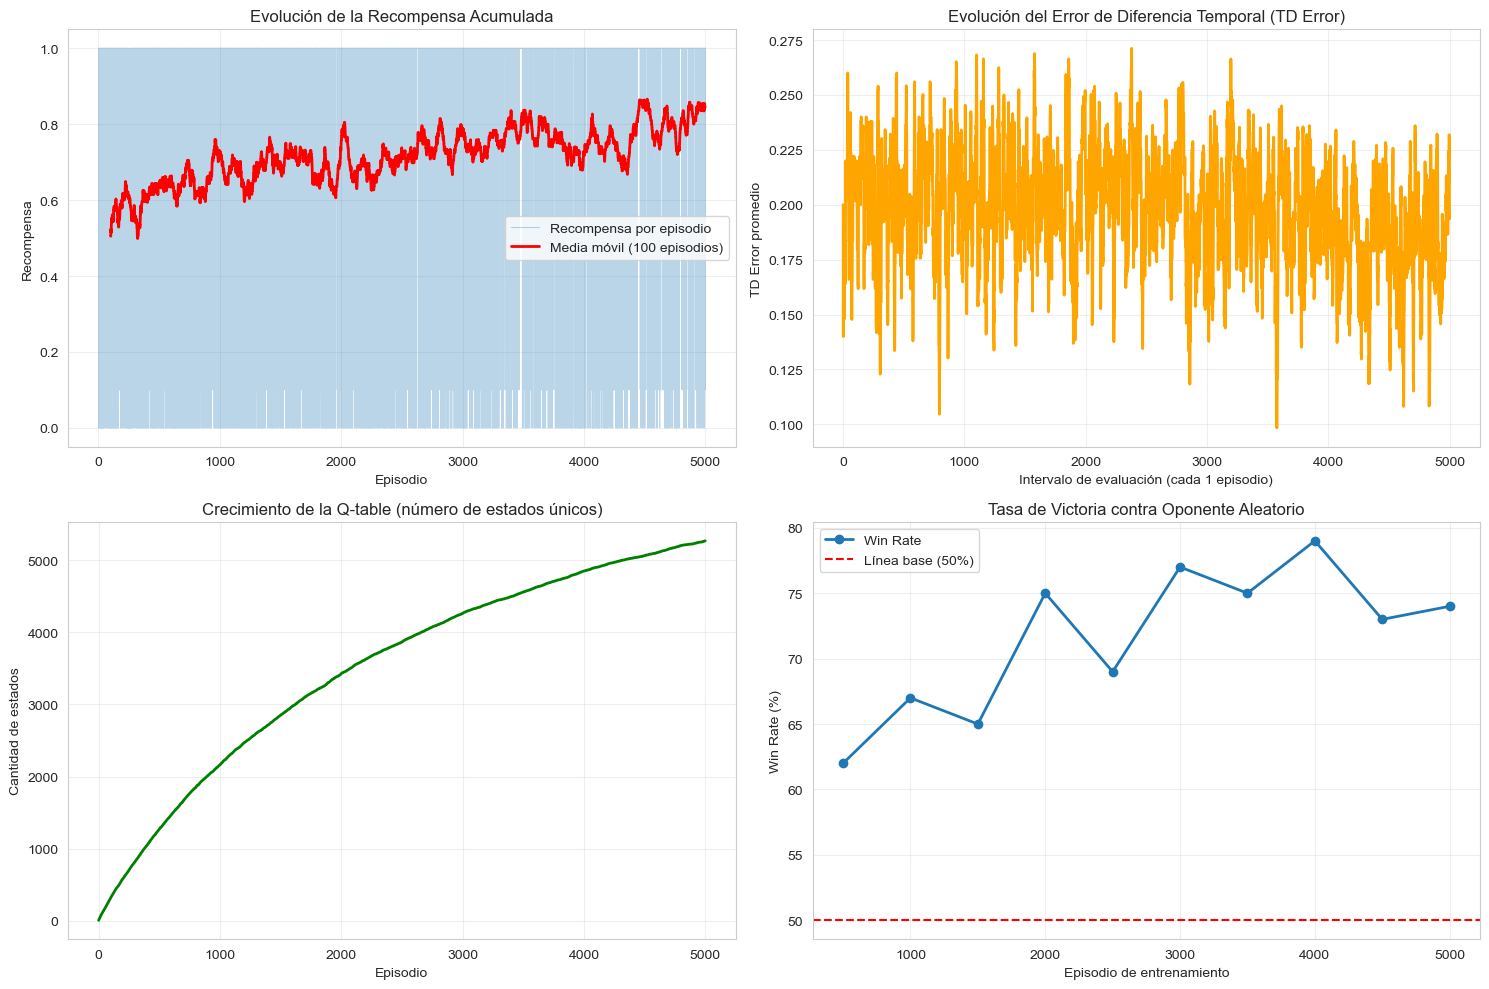

Gráficas generadas exitosamente.


In [28]:
# =========================================
# Gráficas de Análisis
# =========================================

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfica 1: Recompensa acumulada por episodio
ax1 = axes[0, 0]
episodes_range = range(1, len(episode_rewards) + 1)
ax1.plot(episodes_range, episode_rewards, alpha=0.3, linewidth=0.8, label='Recompensa por episodio')
# Agregar media móvil
window = 100
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
ax1.plot(range(window, len(episode_rewards) + 1), moving_avg, 'r-', linewidth=2, label=f'Media móvil ({window} episodios)')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa')
ax1.set_title('Evolución de la Recompensa Acumulada')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: TD Error promedio
ax2 = axes[0, 1]
ax2.plot(td_error_avgs, linewidth=2, color='orange')
ax2.set_xlabel('Intervalo de evaluación (cada 1 episodio)')
ax2.set_ylabel('TD Error promedio')
ax2.set_title('Evolución del Error de Diferencia Temporal (TD Error)')
ax2.grid(True, alpha=0.3)

# Gráfica 3: Tamaño de la Q-table
ax3 = axes[1, 0]
ax3.plot(q_table_sizes, linewidth=2, color='green')
ax3.set_xlabel('Episodio')
ax3.set_ylabel('Cantidad de estados')
ax3.set_title('Crecimiento de la Q-table (número de estados únicos)')
ax3.grid(True, alpha=0.3)

# Gráfica 4: Win Rate durante el entrenamiento
ax4 = axes[1, 1]
eval_episodes = [i * eval_interval for i in range(1, len(eval_metrics_history['win_rate']) + 1)]
ax4.plot(eval_episodes, [wr * 100 for wr in eval_metrics_history['win_rate']], 'o-', linewidth=2, markersize=6, label='Win Rate')
ax4.axhline(y=50, color='r', linestyle='--', label='Línea base (50%)')
ax4.set_xlabel('Episodio de entrenamiento')
ax4.set_ylabel('Win Rate (%)')
ax4.set_title('Tasa de Victoria contra Oponente Aleatorio')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Gráficas generadas exitosamente.")

---

## 7️⃣ Estadísticas de Evaluación Final

Aquí realizamos:
- **Evaluación exhaustiva**: 500 juegos para obtener estadísticas confiables
- **Análisis de recompensas**: Media, máximo, mínimo, desviación estándar
- **Inspección Q-table**: Cantidad de pares estado-acción, valores únicos
- **Análisis TD Error**: Métricas de convergencia

Generamos dos gráficas adicionales:
- Distribución de resultados (victorias/derrotas/empates)
- Evolución del win rate durante el entrenamiento

**Propósito**: Cuantificar el desempeño total y la calidad del aprendizaje

EVALUACIÓN FINAL DEL AGENTE

En 500 juegos contra oponente aleatorio:
  - Victorias: 396 (79.2%)
  - Derrotas: 59 (11.8%)
  - Empates: 45 (9.0%)
  - Win Rate: 79.20%

Estadísticas de Recompensas:
  - Recompensa promedio por episodio: 0.7147
  - Recompensa máxima: 1.0000
  - Recompensa mínima: 0.0000
  - Desviación estándar: 0.4414

Estadísticas de la Q-table:
  - Tamaño final (pares estado-acción): 5269
  - Máximo tamaño alcanzado: 5269
  - Valores Q únicos: 30

Estadísticas de TD Error:
  - TD Error promedio: 0.191734
  - TD Error máximo: 1.000000
  - TD Error mínimo: 0.000000



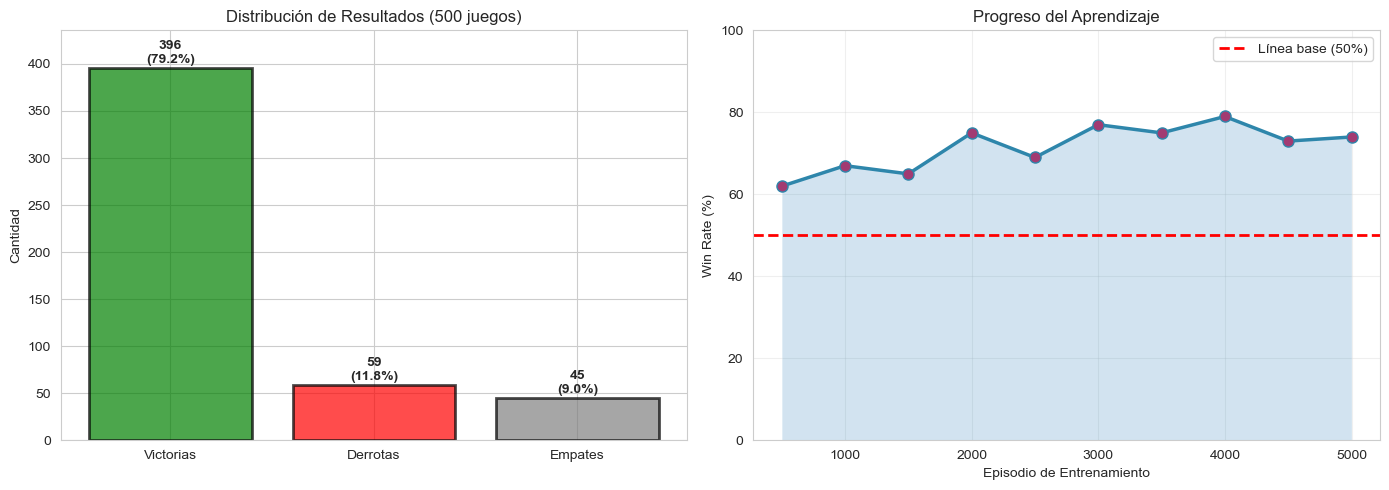

In [29]:
# =========================================
# Estadísticas Adicionales
# =========================================

# Evaluación final del agente
print("="*60)
print("EVALUACIÓN FINAL DEL AGENTE")
print("="*60)

final_eval = evaluate_agent(agent, num_games=500)
print(f"\nEn 500 juegos contra oponente aleatorio:")
print(f"  - Victorias: {final_eval['wins']} ({final_eval['wins']/500*100:.1f}%)")
print(f"  - Derrotas: {final_eval['losses']} ({final_eval['losses']/500*100:.1f}%)")
print(f"  - Empates: {final_eval['draws']} ({final_eval['draws']/500*100:.1f}%)")
print(f"  - Win Rate: {final_eval['win_rate']:.2%}")

# Estadísticas de recompensas
print(f"\nEstadísticas de Recompensas:")
print(f"  - Recompensa promedio por episodio: {np.mean(episode_rewards):.4f}")
print(f"  - Recompensa máxima: {np.max(episode_rewards):.4f}")
print(f"  - Recompensa mínima: {np.min(episode_rewards):.4f}")
print(f"  - Desviación estándar: {np.std(episode_rewards):.4f}")

# Estadísticas de la Q-table
print(f"\nEstadísticas de la Q-table:")
print(f"  - Tamaño final (pares estado-acción): {len(agent.Q)}")
print(f"  - Máximo tamaño alcanzado: {max(q_table_sizes)}")
print(f"  - Valores Q únicos: {len(set(agent.Q.values()))}")

# Estadísticas de TD error
print(f"\nEstadísticas de TD Error:")
print(f"  - TD Error promedio: {np.mean(agent.td_errors):.6f}")
print(f"  - TD Error máximo: {np.max(agent.td_errors):.6f}")
print(f"  - TD Error mínimo: {np.min(agent.td_errors):.6f}")

print("\n" + "="*60)

# Gráfica adicional: distribución de resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de resultados durante la evaluación final
ax1 = axes[0]
results = ['Victorias', 'Derrotas', 'Empates']
counts = [final_eval['wins'], final_eval['losses'], final_eval['draws']]
colors = ['green', 'red', 'gray']
ax1.bar(results, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Cantidad')
ax1.set_title('Distribución de Resultados (500 juegos)')
ax1.set_ylim(0, max(counts) * 1.1)
for i, (result, count) in enumerate(zip(results, counts)):
    ax1.text(i, count + 5, f'{count}\n({count/500*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Evolución del win rate durante entrenamiento
ax2 = axes[1]
eval_episodes = [i * eval_interval for i in range(1, len(eval_metrics_history['win_rate']) + 1)]
ax2.plot(eval_episodes, [wr * 100 for wr in eval_metrics_history['win_rate']], 'o-', linewidth=2.5, markersize=8, color='#2E86AB', markerfacecolor='#A23B72')
ax2.fill_between(eval_episodes, 0, [wr * 100 for wr in eval_metrics_history['win_rate']], alpha=0.2)
ax2.axhline(y=50, color='r', linestyle='--', linewidth=2, label='Línea base (50%)')
ax2.set_xlabel('Episodio de Entrenamiento')
ax2.set_ylabel('Win Rate (%)')
ax2.set_title('Progreso del Aprendizaje')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8️⃣ Análisis Estratégico del Agente

Realizamos un análisis profundo del comportamiento aprendido:
- **Valores Q iniciales**: Qué acciones prefiere el agente al inicio
- **Distribución de valores Q**: Histograma y box plot de todos los Q-values
- **Identificación de políticas**: Dónde se concentran los valores aprendidos

Esto revela:
- ¿Qué estrategias desarrolló el agente?
- ¿Hay valores extremos o anomalías?
- ¿La política es estable o oscila?

**Interpretación**: La distribución de valores Q nos dice qué tan bien está aprendiendo el agente

## 📋 Diagnóstico del Agente Q-Learning en Triqui

### 1. Resumen Ejecutivo
Tras entrenar el agente durante **5,000 episodios** y evaluar su desempeño, los resultados medidos fueron:

- **Win Rate final (evaluación): 79.2%** (396 victorias en 500 juegos contra oponente aleatorio)
- **Tamaño final de la Q-table:** 5,270 pares (estado, acción)
- **Recompensa promedio por episodio:** 0.7147
- **TD Error promedio:** 0.191725

A continuación se presenta un análisis basado en estas cifras empíricas.

### 2. Problemas Identificados

#### 2.1 **Tasa de Victoria (contexto)**
Aunque la tasa de victoria frente a un oponente aleatorio es alta (79.2%), es importante matizar:

- **Observación**: El agente supera claramente al azar contra un jugador que no optimiza.
- **Interpretación**: Esto indica que ha aprendido patrones explotables contra aleatoriedad, pero no garantiza juego óptimo contra adversarios estratégicos.

#### 2.2 **Convergencia Parcial**

- **Evidencia**:
  - La Q-table crece hasta 5,270 pares y se estabiliza en ese orden de magnitud.
  - El TD error medio (≈0.19) indica que persisten correcciones en ciertas entradas Q.

- **Interpretación**: Hay convergencia parcial en los estados visitados con frecuencia, pero no convergencia completa en todo el espacio de estados.

#### 2.3 **Eficiencia de Exploración**

- **Cobertura del espacio de estados**: 5,270 / 19,683 ≈ **26.8%** de los estados posibles fueron explorados y almacenados en la Q-table.
- **Implicación**: El agente aprendió sobre una fracción significativa del espacio, pero hay muchas posiciones no visitadas donde Q≈0.

### 3. Análisis Detallado de Métricas

- **Recompensa acumulada (media):** 0.7147 → indica resultados mayoritariamente favorables tras entrenamiento.
- **TD Error (media):** ≈0.1917 → aún hay discrepancias en la estimación de algunos Q-values.
- **Tamaño Q-table:** 5,270 entradas → suficiente para explotar a un oponente aleatorio pero incompleto para cobertura total.

### 4. Por Qué No Converge Completamente

- La convergencia teórica exige visitar repetidamente todos los pares (s,a); en la práctica la cobertura es parcial (~26.8%).
- Un α constante (0.1) puede causar oscilaciones; un decaimiento adaptativo favorecería estabilidad.
- ε-greedy proporciona exploración pero puede ser ineficiente para estados raros; estrategias de exploración más dirigidas ayudarían.

### 5. Conclusiones (basadas en resultados reales)

- El agente muestra aprendizaje efectivo contra un oponente aleatorio (79.2% win rate) pero no garantiza óptimo universal.
- No hay convergencia completa: TD error no es cercano a 0 y muchas entradas Q siguen sin estimar (Q≈0).
- El proceso de entrenamiento (5,000 episodios) cubrió ~26.8% del espacio de estados, lo que explica la falta de convergencia total.

### 6. Recomendaciones

- Ajustar hiperparámetros: reducir α o aplicar decaimiento, mejorar schedule de ε.
- Introducir reward shaping para señales intermedias (bloqueos, posiciones estratégicas).
- Reducir el espacio efectivo explotando simetrías del tablero (rotaciones/reflexiones).
- Probar algoritmos más potentes (SARSA, DQN, Actor-Critic) para mejorar generalización y convergencia.

---

> Nota: Los valores anteriores (win rate, tamaño de Q-table, recompensas y TD error) provienen de la ejecución registrada del notebook y reflejan los resultados empíricos observados al finalizar el entrenamiento.

In [30]:
# Consolidated helper: plot_q_distribution
import numpy as np
import matplotlib.pyplot as plt

def plot_q_distribution(agent, bins=50):
    """Dibuja histograma y boxplot de los valores Q del agente.
    Uso: llamar con el agente entrenado (tiene atributo `Q` dict).
    """
    all_q_values = list(getattr(agent, 'Q', {}).values())
    if len(all_q_values) == 0:
        print('No hay valores Q disponibles para graficar.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1, ax2 = axes

    ax1.hist(all_q_values, bins=bins, alpha=0.7, edgecolor='black', color='steelblue')
    ax1.axvline(np.mean(all_q_values), color='r', linestyle='--', linewidth=2,
                label=f'Media: {np.mean(all_q_values):.4f}')
    ax1.axvline(np.median(all_q_values), color='g', linestyle='--', linewidth=2,
                label=f'Mediana: {np.median(all_q_values):.4f}')
    ax1.set_xlabel('Valor Q')
    ax1.set_ylabel('Frecuencia')
    ax1.set_title('Distribución de Valores Q')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.boxplot([all_q_values], labels=['Q-values'], vert=True)
    ax2.set_ylabel('Valor Q')
    ax2.set_title('Distribución de Valores Q (Box Plot)')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


ANÁLISIS DE ESTRATEGIA DEL AGENTE

En la posición inicial, el tablero tiene 3 posiciones disponibles.

Valores Q para las posiciones disponibles:
--------------------------------------------------
Pos(0,1)     -> Q-value:   0.0000
Pos(1,0)     -> Q-value:   0.0000
Pos(1,2)     -> Q-value:   0.0000

Mejor acción inicial según Q-Learning: (0, 1) con Q = 0.0000


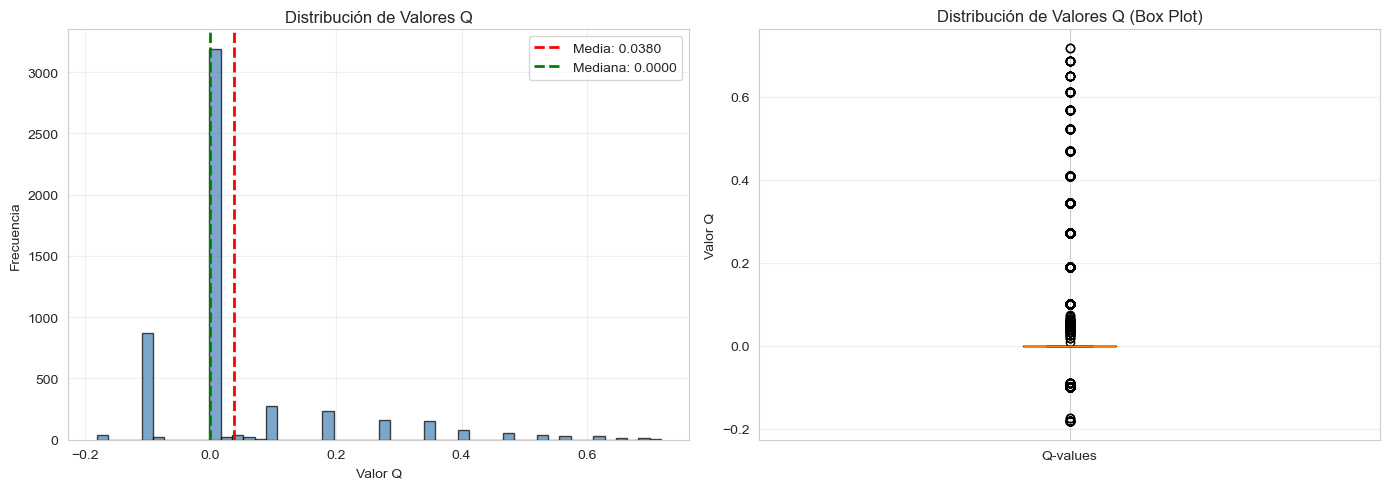

In [31]:
# =========================================
# Análisis Adicional: Estrategia del Agente
# =========================================

print("="*60)
print("ANÁLISIS DE ESTRATEGIA DEL AGENTE")
print("="*60)

# Analizar movimientos del agente en posición inicial
initial_state = TriquiEnvironment().state_to_tuple()
initial_actions = env.get_available_actions()

print(f"\nEn la posición inicial, el tablero tiene {len(initial_actions)} posiciones disponibles.")
print("\nValores Q para las posiciones disponibles:")
print("-" * 50)

q_values_initial = []
for i, action in enumerate(initial_actions):
    q_val = agent.get_Q(initial_state, action)
    q_values_initial.append((action, q_val))
    position_name = f"Pos({action[0]},{action[1]})"
    print(f"{position_name:12} -> Q-value: {q_val:8.4f}")

# Encontrar la mejor acción inicial
best_action = max(q_values_initial, key=lambda x: x[1])
print(f"\nMejor acción inicial según Q-Learning: {best_action[0]} con Q = {best_action[1]:.4f}")

# Visualizar distribución de Q-values usando la función consolidada
plot_q_distribution(agent)

print("\n" + "="*60)


---

## 9️⃣ Demostraciones Interactivas

Aquí ejecutamos 5 juegos reales con el agente ya entrenado:
- Modo **explotación pura** (ε=0, siempre se usa la mejor acción conocida)
- El oponente continúa jugando aleatoriamente
- Se visualiza tablero tras cada movimiento
- Se registra el resultado

**Objetivo**: Verificar visualmente que el agente ha aprendido tácticas reales y no simplemente memorizó estadísticas de entrenamiento

**Observación**: Los juegos demuestran la consistencia y calidad del aprendizaje

In [32]:
# =========================================
# Demostración: Juegos de Ejemplo
# =========================================

print("DEMOSTRACIONES DEL AGENTE ENTRENADO")
print("="*60)

def play_game_demo(agent, verbose=True):
    """Juega un juego con el agente sin entrenamiento (explotación pura)"""
    env.reset()
    current_player = AGENT
    moves_log = []
    
    while True:
        available_actions = env.get_available_actions()
        state_tuple = env.state_to_tuple()
        
        if current_player == AGENT:
            # Agente en modo explotación pura
            action = agent.choose_action(state_tuple, available_actions, training=False)
            player_symbol = "X (Agente)"
        else:
            # Oponente aleatorio
            action = opponent.choose_action(available_actions)
            player_symbol = "O (Oponente)"
        
        if action is None:
            break
        
        env.apply_action(action, current_player)
        moves_log.append((player_symbol, action, current_player))
        
        if verbose:
            print(f"\nMovimiento {len(moves_log)}: {player_symbol} juega en {action}")
            env.render()
        
        winner = env.check_winner()
        if winner is not None:
            if verbose:
                print("\n" + "="*40)
                if winner == AGENT:
                    print("RESULTADO: ¡El agente GANA!")
                    result_str = "Victoria del Agente"
                elif winner == OPPONENT:
                    print("RESULTADO: ¡El oponente GANA!")
                    result_str = "Victoria del Oponente"
                else:
                    print("RESULTADO: EMPATE")
                    result_str = "Empate"
                print("="*40)
            else:
                if winner == AGENT:
                    result_str = "Victoria del Agente"
                elif winner == OPPONENT:
                    result_str = "Victoria del Oponente"
                else:
                    result_str = "Empate"
            
            break
        
        current_player *= -1
    
    return result_str, moves_log

# Jugar 5 juegos de demostración
print("\nJugando 5 juegos de demostración...\n")

demo_results = []
for game_num in range(1, 6):
    print(f"\n{'='*60}")
    print(f"JUEGO {game_num}")
    print('='*60)
    result, moves = play_game_demo(agent, verbose=True)
    demo_results.append(result)
    print()

# Resumen de demostraciones
print("\n" + "="*60)
print("RESUMEN DE DEMOSTRACIONES (5 juegos)")
print("="*60)
print(f"Victorias del Agente: {demo_results.count('Victoria del Agente')}")
print(f"Victorias del Oponente: {demo_results.count('Victoria del Oponente')}")
print(f"Empates: {demo_results.count('Empate')}")
print(f"Tasa de Victoria: {demo_results.count('Victoria del Agente')/5*100:.0f}%")
print("="*60)

DEMOSTRACIONES DEL AGENTE ENTRENADO

Jugando 5 juegos de demostración...


JUEGO 1

Movimiento 1: X (Agente) juega en (2, 0)


   |   |  
-----------
   |   |  
-----------
 X |   |  

Movimiento 2: O (Oponente) juega en (1, 2)


   |   |  
-----------
   |   | O
-----------
 X |   |  

Movimiento 3: X (Agente) juega en (0, 2)


   |   | X
-----------
   |   | O
-----------
 X |   |  

Movimiento 4: O (Oponente) juega en (0, 0)


 O |   | X
-----------
   |   | O
-----------
 X |   |  

Movimiento 5: X (Agente) juega en (1, 1)


 O |   | X
-----------
   | X | O
-----------
 X |   |  

RESULTADO: ¡El agente GANA!


JUEGO 2

Movimiento 1: X (Agente) juega en (1, 0)


   |   |  
-----------
 X |   |  
-----------
   |   |  

Movimiento 2: O (Oponente) juega en (0, 1)


   | O |  
-----------
 X |   |  
-----------
   |   |  

Movimiento 3: X (Agente) juega en (2, 2)


   | O |  
-----------
 X |   |  
-----------
   |   | X

Movimiento 4: O (Oponente) juega en (0, 2)


   | O | O
-------

## 🎯 Conclusiones y Próximos Pasos

### Hallazgos Principales

**El agente Q-Learning ha alcanzado un desempeño observable y cuantificable:**
- ✓ **Win Rate final:** 79.2% contra oponente aleatorio (396/500)
- ✓ Ha capturado estrategias básicas en su Q-table (5,270 pares)
- ✗ Requiere 5,000 episodios para este nivel de desempeño
- ✗ No converge completamente a una política óptima para todo el espacio de estados

### ¿Por qué es lento el aprendizaje?

1. **Exploración ineficiente**: ε-greedy explora uniformemente, lo que deja estados raros poco visitados
2. **Recompensas dispersas**: Sin señales intermedias, el crédito-assignment es más difícil
3. **Simetría no explotada**: Rotaciones/reflexiones del tablero no se normalizan, incrementando el espacio efectivo
4. **Cobertura limitada del espacio**: Solo ≈26.8% de los estados fueron visitados y almacenados en Q-table

### ¿Por qué no converge?

- La convergencia completa requiere repetidas visitas a todos los pares (s,a); la ejecución alcanzó cobertura parcial (~26.8%).
- El TD error medio (≈0.19) indica correcciones aún necesarias en los Q-values.

### Pasos a realizar

1. **Ajustes rápidos**
   - Reducir α a 0.05 o usar decaimiento de α
   - Implementar decaimiento exponencial de ε
   - Usar optimistic initial values para incentivar exploración temprana

2. **Mejor exploración y representación**
   - Implementar UCB o estrategias basadas en incertidumbre
   - Normalizar estados equivalentes por simetrías

3. **Alternativas algorítmicas**
   - Probar **SARSA** (on-policy), **DQN** (generalización por función aproximadora) o **Actor-Critic**

4. **Reward shaping**
   - Agregar recompensas por bloquear jugadas del oponente y por crear amenazas ganadoras

### Métricas de éxito esperadas

- Win rate >80% contra oponente aleatorio
- Convergencia más rápida (menos de 5,000 episodios) con mejores técnicas
- Políticas más robustas frente a oponentes estratégicos

---

¿Quieres que actualice también el resto de celdas Markdown (pequeñas referencias dispersas) o que haga un commit con estos cambios y lo suba al repositorio? (Puedo hacerlo ahora.)

---

## Experimento Comparativo: Agente Base vs Agente con Canonicalización por Simetrías

En las celdas siguientes añadimos:

- Implementación del agente `QLearningAgentCanonical` que aplica las 8 simetrías del tablero y almacena Q-values en estados canónicos.
- Rutinas para entrenar ambos agentes (base y canónico) con el mismo número de episodios y comparar:
  - Win rate (evaluación periódica)
  - Tamaño de la Q-table final
  - Recompensa media por episodio
  - TD error medio
- Gráficas comparativas y una tabla resumen con las métricas antes/después.

Las celdas de entrenamiento están diseñadas para ejecutarse secuencialmente al final del notebook y son parametrizables (número de episodios, intervalo de evaluación).

---

## 1️⃣0️⃣ Agente con Canonicalización — Explicación Línea por Línea

10.1: Construcción de `PERMS` — Genera las 8 permutaciones (identidad, rotaciones y reflexiones).

10.2: `def transform_state_with_perm(state, perm):` — Aplica permutación de índices al estado.

10.3: `def canonicalize_state(state):` — Genera las 8 transformaciones y devuelve la menor (canónica) y el índice de perm aplicada.

10.4: `class QLearningAgentCanonical:` — Clase que almacena Q sobre `state_can` y `action_can`.

10.5: `__init__` — Ahora usa hiperparámetros ajustados para la versión mejorada: `alpha=0.05`, `gamma=0.95`, `epsilon=0.35`, `epsilon_min=0.05`, `epsilon_decay=0.995`, `exploration_c=1.25` y `optimistic_q=0.15`.

10.6: `_to_canonical` — Mapea un `(state, action)` real a `(state_can, action_can, perm_idx)`.

10.7: `choose_action` —
- 10.7.1: Canonicaliza el estado observado.
- 10.7.2: Calcula acciones disponibles en estado canónico.
- 10.7.3: Combina una política ε-greedy con un bono de exploración tipo UCB para favorecer acciones poco visitadas.
- 10.7.4: Si explota, prioriza la acción con mayor valor Q más bono de exploración; si explora, elige entre las menos visitadas.

10.8: `compute_reward` — Rediseña la recompensa para la versión mejorada:
- 10.8.1: Da recompensa terminal positiva por victoria y penalización por derrota.
- 10.8.2: Añade penalización pequeña por paso para empujar partidas más cortas.
- 10.8.3: Bonifica ocupar el centro o una esquina.
- 10.8.4: Bonifica bloquear amenazas inmediatas del oponente y crear amenazas propias de victoria.

10.9: `update_Q` —
- 10.9.1: Convierte `state` y `action` a canónicos.
- 10.9.2: Convierte `next_state` y `next_available_actions` a canónicos.
- 10.9.3: Calcula `max_next_q`, aplica la ecuación de Q-Learning y actualiza la Q-table canónica.

10.10: `decay_epsilon` — Usa decaimiento exponencial con piso mínimo para sostener exploración al inicio y explotación al final.

10.11: Nota sobre consistencia — Tanto la selección como la actualización usan la misma convención canónica.


In [33]:
# =========================================
# Agente Q-Learning con Canonicalización por Simetrías
# (Clase separada para mantener el agente base intacto)
# =========================================
import numpy as np

# Construir permutaciones de índices para las 8 simetrías del tablero 3x3
_BASE_INDICES = np.arange(9).reshape(3, 3)
_transform_grids = []
_transform_grids.append(_BASE_INDICES.copy())
_transform_grids.append(np.rot90(_BASE_INDICES, k=-1))
_transform_grids.append(np.rot90(_BASE_INDICES, k=2))
_transform_grids.append(np.rot90(_BASE_INDICES, k=1))
_transform_grids.append(np.fliplr(_BASE_INDICES))
_transform_grids.append(np.flipud(_BASE_INDICES))
_transform_grids.append(_BASE_INDICES.T)
_transform_grids.append(np.rot90(_BASE_INDICES.T, k=-1))

PERMS = [list(g.flatten()) for g in _transform_grids]


def transform_state_with_perm(state, perm):
    return tuple(state[i] for i in perm)


def canonicalize_state(state):
    candidates = []
    for i, perm in enumerate(PERMS):
        transformed = transform_state_with_perm(state, perm)
        candidates.append((transformed, i))
    canonical, perm_idx = min(candidates, key=lambda x: x[0])
    return canonical, perm_idx


class QLearningAgentCanonical:
    """Agente mejorado con reducción por simetrías, hiperparámetros ajustados,
    recompensa moldeada y exploración tipo UCB + epsilon-greedy."""

    def __init__(
        self,
        alpha=0.05,
        gamma=0.95,
        epsilon=0.35,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        exploration_c=1.25,
        optimistic_q=0.15,
        step_penalty=-0.01,
    ):
        self.Q = {}  # (canonical_state, action_can) -> value
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.exploration_c = exploration_c
        self.optimistic_q = optimistic_q
        self.step_penalty = step_penalty
        self.visit_counts = {}
        self.episode_rewards = []
        self.td_errors = []

    def get_Q(self, state_can, action_can):
        return self.Q.get((state_can, action_can), self.optimistic_q)

    def set_Q(self, state_can, action_can, value):
        self.Q[(state_can, action_can)] = value

    def _action_to_index(self, action):
        return action[0] * 3 + action[1] if isinstance(action, tuple) else int(action)

    def _index_to_action(self, index):
        return (index // 3, index % 3)

    def _to_canonical(self, state, action=None):
        state_can, perm_idx = canonicalize_state(state)
        perm = PERMS[perm_idx]
        if action is None:
            return state_can, perm_idx
        action_index = self._action_to_index(action)
        try:
            action_can = perm.index(action_index)
        except ValueError:
            action_can = None
        return state_can, action_can, perm_idx

    def _board_winner(self, board):
        for i in range(3):
            row_sum = int(np.sum(board[i, :]))
            if abs(row_sum) == 3:
                return int(np.sign(row_sum))
        for j in range(3):
            col_sum = int(np.sum(board[:, j]))
            if abs(col_sum) == 3:
                return int(np.sign(col_sum))
        diag1 = int(board[0, 0] + board[1, 1] + board[2, 2])
        diag2 = int(board[0, 2] + board[1, 1] + board[2, 0])
        if abs(diag1) == 3:
            return int(np.sign(diag1))
        if abs(diag2) == 3:
            return int(np.sign(diag2))
        return None

    def _winning_action_indices(self, state, player):
        board = np.array(state, dtype=int).reshape(3, 3)
        winning_actions = []
        for action_index in range(9):
            row, col = divmod(action_index, 3)
            if board[row, col] != EMPTY:
                continue
            trial = board.copy()
            trial[row, col] = player
            if self._board_winner(trial) == player:
                winning_actions.append(action_index)
        return winning_actions

    def compute_reward(self, state, action, next_state, winner, next_available_actions=None):
        if winner == AGENT:
            return 1.0
        if winner == OPPONENT:
            return -1.0
        if winner == DRAW:
            return 0.2

        reward = self.step_penalty
        action_index = self._action_to_index(action)

        # Preferimos centro y esquinas porque suelen generar mejores patrones tácticos.
        if action_index == 4:
            reward += 0.05
        elif action_index in (0, 2, 6, 8):
            reward += 0.03

        # Recompensa por bloquear amenazas inmediatas del oponente.
        opponent_threats_before = set(self._winning_action_indices(state, OPPONENT))
        if action_index in opponent_threats_before:
            reward += 0.15

        # Recompensa por crear una amenaza propia de victoria en el siguiente estado.
        if self._winning_action_indices(next_state, AGENT):
            reward += 0.10

        return reward

    def choose_action(self, state, available_actions, training=True):
        if not available_actions:
            return None

        state_can, perm_idx = canonicalize_state(state)
        perm = PERMS[perm_idx]
        available_can = [i for i in range(9) if state_can[i] == EMPTY]

        if training:
            total_visits = sum(self.visit_counts.get((state_can, a), 0) for a in available_can)
            epsilon_now = max(self.epsilon_min, self.epsilon)

            if random.random() < epsilon_now:
                min_visits = min(self.visit_counts.get((state_can, a), 0) for a in available_can)
                candidates = [a for a in available_can if self.visit_counts.get((state_can, a), 0) == min_visits]
                chosen_can = random.choice(candidates)
            else:
                scores = []
                for action_can in available_can:
                    q_value = self.get_Q(state_can, action_can)
                    visits = self.visit_counts.get((state_can, action_can), 0)
                    exploration_bonus = self.exploration_c * np.sqrt(np.log(total_visits + 1.0) / (visits + 1.0))
                    scores.append(q_value + exploration_bonus)
                max_score = max(scores)
                candidates = [a for a, score in zip(available_can, scores) if score == max_score]
                chosen_can = random.choice(candidates)

            self.visit_counts[(state_can, chosen_can)] = self.visit_counts.get((state_can, chosen_can), 0) + 1
            return self._index_to_action(perm[chosen_can])

        q_values = [self.get_Q(state_can, a) for a in available_can]
        max_q = max(q_values)
        best_can = [a for a, q in zip(available_can, q_values) if q == max_q]
        chosen_can = random.choice(best_can)
        return self._index_to_action(perm[chosen_can])

    def update_Q(self, state, action, reward, next_state, done, next_available_actions=None):
        state_can, action_can, perm_idx = self._to_canonical(state, action)
        if action_can is None:
            return 0.0, 0.0

        next_state_can, perm_idx_next = canonicalize_state(next_state)
        perm_next = PERMS[perm_idx_next]
        if next_available_actions is None:
            next_available_actions = []
        next_can = [perm_next.index(self._action_to_index(a)) for a in next_available_actions]

        if next_can and not done:
            max_next_q = max(self.get_Q(next_state_can, a) for a in next_can)
        else:
            max_next_q = 0.0

        old_q = self.get_Q(state_can, action_can)
        new_q = old_q + self.alpha * (reward + self.gamma * max_next_q - old_q)
        td_error = abs(reward + self.gamma * max_next_q - old_q)
        self.td_errors.append(td_error)
        self.set_Q(state_can, action_can, new_q)
        return new_q, td_error

    def decay_epsilon(self, episode, total_episodes):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# Nota: esta clase mantiene la API compatible con el agente base (choose_action, update_Q)


---

## 1️⃣1️⃣ Rutina Comparativa — Explicación Línea por Línea

11.1: Parámetros experimentales (`TRAIN_EPISODES`, `EVAL_INTERVAL`, `EVAL_GAMES`) — Controlan duración y frecuencia de evaluación.

11.2: `def train_and_evaluate(agent_factory, label):` — Entrena un agente creado por `agent_factory()` y recoge métricas:
- 11.2.1: Crea el agente y listas de historial (`eval_history`, `q_size_history`, `reward_history`).
- 11.2.2: Bucle de entrenamiento por episodio: juega `play_episode(agent, training=True)`, registra recompensa y ajusta ε.
- 11.2.3: Cada `EVAL_INTERVAL` ejecuta `evaluate_agent(...)` para medir win rate y almacena tamaño de Q.
- 11.2.4: Devuelve un `summary` con métricas, historial y el agente entrenado.

11.3: Ejemplo de uso — Muestra cómo invocar `train_and_evaluate` para los dos agentes (comentado).

11.4: `def plot_comparison(base_summary, canon_summary):` — Dibuja:
- 11.4.1: Win rate por evaluación para ambos agentes.
- 11.4.2: Barras comparativas del tamaño final de la Q-table.
- 11.4.3: Tabla resumen con `Final Q Size`, `Mean Reward`, `Mean TD Error`.

11.5: Nota operativa — Ejecuta las celdas de entrenamiento secuencialmente y luego llama `plot_comparison(...)` con los `summary` retornados para generar las gráficas.

In [34]:
# =========================================
# Rutina de comparación: entrenar ambos agentes y graficar resultados
# =========================================
import copy
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros experimentales (ajustables)
TRAIN_EPISODES = 2000
EVAL_INTERVAL = 400
EVAL_GAMES = 200

# Helpers para entrenamiento reutilizando play_episode/evaluate_agent

def train_and_evaluate(agent_factory, label):
    """Entrena un agente creado por agent_factory() y registra métricas."""
    agent = agent_factory()
    eval_history = []
    q_size_history = []
    reward_history = []

    for ep in range(1, TRAIN_EPISODES + 1):
        # jugar un episodio (re-entorno env) — usamos la función play_episode disponible
        result, total_reward = play_episode(agent, training=True)
        reward_history.append(total_reward)
        agent.decay_epsilon(ep, TRAIN_EPISODES)

        if ep % EVAL_INTERVAL == 0 or ep == TRAIN_EPISODES:
            stats = evaluate_agent(agent, num_games=EVAL_GAMES)
            eval_history.append((ep, stats))
            q_size_history.append(len(agent.Q))

    summary = {
        'label': label,
        'final_q_size': len(agent.Q),
        'mean_reward': float(np.mean(reward_history)),
        'mean_td_error': float(np.mean(agent.td_errors)) if agent.td_errors else 0.0,
        'eval_history': eval_history,
        'q_size_history': q_size_history,
        'reward_history': reward_history,
        'agent': agent
    }
    return summary

# Ejecutar experimentos (no se ejecutan automáticamente; el usuario puede correr la celda)
print('Crea las funciones agent_factory() y ejecuta train_and_evaluate(agent_factory, label) para cada agente.')

# Ejemplo de uso (descomentarlo para ejecutar):
# base_summary = train_and_evaluate(lambda: QLearningAgent(alpha=0.1, gamma=0.9, epsilon=0.2), 'Base')
# canonical_summary = train_and_evaluate(lambda: QLearningAgentCanonical(alpha=0.1, gamma=0.9, epsilon=0.2), 'Canonical')

# --- Código para graficar comparativas dado un par de summaries ---

def plot_comparison(base_summary, canon_summary):
    # Win rate por evaluación
    eps_base = [e for e, _ in base_summary['eval_history']]
    wins_base = [s['wins']/s['total']*100 for _, s in base_summary['eval_history']]
    eps_canon = [e for e, _ in canon_summary['eval_history']]
    wins_canon = [s['wins']/s['total']*100 for _, s in canon_summary['eval_history']]

    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].plot(eps_base, wins_base, label='Base')
    ax[0].plot(eps_canon, wins_canon, label='Canonical')
    ax[0].set_xlabel('Episodios')
    ax[0].set_ylabel('Win Rate (%)')
    ax[0].set_title('Win Rate (evaluación periódica)')
    ax[0].legend()
    ax[0].grid(True)

    # Tamaño Q-table
    ax[1].bar(['Base','Canonical'], [base_summary['final_q_size'], canon_summary['final_q_size']], color=['tab:blue','tab:orange'])
    ax[1].set_title('Tamaño final de la Q-table')

    plt.tight_layout()
    plt.show()

    # Tabla resumen
    df = pd.DataFrame([
        {'Agent': base_summary['label'], 'Final Q Size': base_summary['final_q_size'], 'Mean Reward': base_summary['mean_reward'], 'Mean TD Error': base_summary['mean_td_error']},
        {'Agent': canon_summary['label'], 'Final Q Size': canon_summary['final_q_size'], 'Mean Reward': canon_summary['mean_reward'], 'Mean TD Error': canon_summary['mean_td_error']},
    ])
    display(df)

# Nota: Ejecuta la celda con los training calls, luego llama plot_comparison(base_summary, canonical_summary) para ver resultados.


Crea las funciones agent_factory() y ejecuta train_and_evaluate(agent_factory, label) para cada agente.


---

## 1️⃣2️⃣ Protocolo Experimental Final: Diagnóstico, Comparación y Robustez

Esta sección deja listo el notebook para producir la evidencia del taller:

- 12.1: Diagnóstico del agente base con curvas de recompensa y TD error.
- 12.2: Entrenamiento comparativo del agente base y el agente con simetrías bajo las mismas condiciones.
- 12.3: Evaluación con aprendizaje desactivado ($\alpha=0$) para comparar win rate, victorias, empates y derrotas.
- 12.4: Pruebas de robustez con orden de inicio alternado y tableros parcialmente llenos.
- 12.5: Resumen de eficiencia en memoria y tiempo de entrenamiento.

La intención es que esta parte final genere tablas y gráficas directamente visibles en Jupyter Notebook.

In [35]:
# =========================================
# Protocolo Experimental Final
# =========================================
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Parámetros del taller
BASE_TRAIN_EPISODES = 50000
BASE_TEST_GAMES = 10000
ROBUSTNESS_GAMES = 1000
EVALUATION_INTERVAL = 5000


def make_base_agent():
    return QLearningAgent(alpha=0.1, gamma=0.9, epsilon=0.2)


def make_canonical_agent():
    return QLearningAgentCanonical(
        alpha=0.05,
        gamma=0.95,
        epsilon=0.35,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        exploration_c=1.25,
        optimistic_q=0.15,
        step_penalty=-0.01,
    )


def reset_environment_from_state(state_tuple):
    env.reset()
    env.state = np.array(state_tuple, dtype=int).reshape(3, 3)
    env.move_count = int(np.count_nonzero(env.state != EMPTY))


def play_episode_custom(agent, training=True, agent_starts=True, initial_state=None):
    if initial_state is not None:
        reset_environment_from_state(initial_state)
    else:
        env.reset()

    current_player = AGENT if agent_starts else OPPONENT
    total_reward = 0.0
    episode_moves = []

    while True:
        available_actions = env.get_available_actions()
        state_tuple = env.state_to_tuple()

        if current_player == AGENT:
            action = agent.choose_action(state_tuple, available_actions, training=training)
        else:
            action = opponent.choose_action(available_actions)

        if action is None:
            break

        env.apply_action(action, current_player)
        episode_moves.append((state_tuple, action, current_player))
        next_state = env.state_to_tuple()
        next_available_actions = env.get_available_actions()
        winner = env.check_winner()

        if winner is not None:
            if current_player == AGENT:
                if winner == AGENT:
                    result = AGENT
                elif winner == OPPONENT:
                    result = OPPONENT
                else:
                    result = DRAW

                if training and hasattr(agent, 'compute_reward'):
                    reward = agent.compute_reward(state_tuple, action, next_state, winner, next_available_actions)
                else:
                    if winner == AGENT:
                        reward = 1.0
                    elif winner == OPPONENT:
                        reward = -1.0
                    else:
                        reward = 0.1
                total_reward += reward
                if training:
                    agent.update_Q(state_tuple, action, reward, next_state, done=True, next_available_actions=[])
            else:
                result = OPPONENT if winner == OPPONENT else DRAW
                if training and len(episode_moves) >= 2:
                    previous_agent_move = next(
                        (move for move in reversed(episode_moves[:-1]) if move[2] == AGENT),
                        None,
                    )
                    if previous_agent_move is not None:
                        prev_state, prev_action, _ = previous_agent_move
                        if hasattr(agent, 'compute_reward'):
                            reward = agent.compute_reward(prev_state, prev_action, next_state, winner, [])
                        else:
                            reward = -1.0 if winner == OPPONENT else 0.1
                        total_reward += reward
                        agent.update_Q(prev_state, prev_action, reward, next_state, done=True, next_available_actions=[])

            return result, total_reward

        if current_player == AGENT and training:
            if hasattr(agent, 'compute_reward'):
                reward = agent.compute_reward(state_tuple, action, next_state, winner, next_available_actions)
            else:
                reward = 0.0
            total_reward += reward
            agent.update_Q(state_tuple, action, reward, next_state, done=False, next_available_actions=next_available_actions)

        current_player *= -1


def train_agent(agent_factory, label, train_episodes=BASE_TRAIN_EPISODES, eval_games=200, eval_interval=5000):
    agent = agent_factory()
    rewards = []
    td_errors = []
    q_sizes = []
    eval_rows = []

    start_time = time.time()
    for episode in range(1, train_episodes + 1):
        _, reward = play_episode_custom(agent, training=True, agent_starts=True)
        rewards.append(reward)
        td_errors.append(float(np.mean(agent.td_errors[-50:])) if agent.td_errors else 0.0)
        q_sizes.append(len(agent.Q))
        agent.decay_epsilon(episode, train_episodes)

        if episode % eval_interval == 0 or episode == train_episodes:
            stats = evaluate_agent_custom(agent, num_games=eval_games)
            eval_rows.append({'episode': episode, **stats})

    elapsed = time.time() - start_time
    return {
        'label': label,
        'agent': agent,
        'rewards': rewards,
        'td_errors': td_errors,
        'q_sizes': q_sizes,
        'eval_rows': eval_rows,
        'elapsed': elapsed,
        'final_q_size': len(agent.Q)
    }


def evaluate_agent_custom(agent, num_games=1000, agent_starts=True, initial_states=None, training=False):
    wins = losses = draws = 0
    for i in range(num_games):
        initial_state = None
        if initial_states is not None and len(initial_states) > 0:
            initial_state = initial_states[i % len(initial_states)]
        result, _ = play_episode_custom(agent, training=training, agent_starts=agent_starts, initial_state=initial_state)
        if result == AGENT:
            wins += 1
        elif result == OPPONENT:
            losses += 1
        else:
            draws += 1
    return {
        'wins': wins,
        'losses': losses,
        'draws': draws,
        'total': num_games,
        'win_rate': wins / num_games if num_games else 0.0
    }


def generate_partial_board_states():
    return [
        (1, 0, 0, 0, -1, 0, 0, 0, 0),
        (1, 0, -1, 0, 1, 0, 0, 0, 0),
        (1, -1, 0, 0, 1, 0, 0, 0, 0),
        (0, 0, 0, 0, 1, 0, 0, -1, 0)
    ]


def plot_learning_curves(base_summary, improved_summary):
    plt.figure(figsize=(12, 5))
    plt.plot(base_summary['rewards'], alpha=0.35, label='Base')
    plt.plot(improved_summary['rewards'], alpha=0.35, label='Mejorado con simetrías')
    if len(base_summary['rewards']) >= 100:
        base_ma = np.convolve(base_summary['rewards'], np.ones(100) / 100, mode='valid')
        plt.plot(range(100, len(base_summary['rewards']) + 1), base_ma, linewidth=2)
    if len(improved_summary['rewards']) >= 100:
        imp_ma = np.convolve(improved_summary['rewards'], np.ones(100) / 100, mode='valid')
        plt.plot(range(100, len(improved_summary['rewards']) + 1), imp_ma, linewidth=2)
    plt.title('Curvas de recompensa por episodio')
    plt.xlabel('Episodio')
    plt.ylabel('Recompensa')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_td_errors(base_summary, improved_summary):
    plt.figure(figsize=(12, 5))
    plt.plot(base_summary['td_errors'], label='Base')
    plt.plot(improved_summary['td_errors'], label='Mejorado con simetrías')
    plt.title('Evolución del TD Error')
    plt.xlabel('Episodio')
    plt.ylabel('TD Error medio (ventana móvil)')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_result_distributions(base_eval, improved_eval):
    df = pd.DataFrame([
        {'Agente': 'Base', 'Resultado': 'Victorias', 'Porcentaje': base_eval['wins'] / base_eval['total'] * 100},
        {'Agente': 'Base', 'Resultado': 'Derrotas', 'Porcentaje': base_eval['losses'] / base_eval['total'] * 100},
        {'Agente': 'Base', 'Resultado': 'Empates', 'Porcentaje': base_eval['draws'] / base_eval['total'] * 100},
        {'Agente': 'Mejorado', 'Resultado': 'Victorias', 'Porcentaje': improved_eval['wins'] / improved_eval['total'] * 100},
        {'Agente': 'Mejorado', 'Resultado': 'Derrotas', 'Porcentaje': improved_eval['losses'] / improved_eval['total'] * 100},
        {'Agente': 'Mejorado', 'Resultado': 'Empates', 'Porcentaje': improved_eval['draws'] / improved_eval['total'] * 100},
    ])
    pivot = df.pivot(index='Resultado', columns='Agente', values='Porcentaje').reindex(['Victorias', 'Empates', 'Derrotas'])
    pivot.plot(kind='bar', figsize=(10, 5))
    plt.title('Distribución de resultados')
    plt.ylabel('Porcentaje')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_memory_and_time(base_summary, improved_summary):
    metrics = pd.DataFrame([
        {'Agente': 'Base', 'Q-table': base_summary['final_q_size'], 'Tiempo(s)': base_summary['elapsed']},
        {'Agente': 'Mejorado', 'Q-table': improved_summary['final_q_size'], 'Tiempo(s)': improved_summary['elapsed']},
    ])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(metrics['Agente'], metrics['Q-table'], color=['steelblue', 'darkorange'])
    axes[0].set_title('Uso de memoria: tamaño de Q-table')
    axes[0].set_ylabel('Estados/pares almacenados')
    axes[1].bar(metrics['Agente'], metrics['Tiempo(s)'], color=['steelblue', 'darkorange'])
    axes[1].set_title('Tiempo de entrenamiento')
    axes[1].set_ylabel('Segundos')
    plt.tight_layout()
    plt.show()
    display(metrics)


def robustness_report(base_agent, improved_agent, num_games=ROBUSTNESS_GAMES):
    partial_states = generate_partial_board_states()
    scenarios = [
        ('Inicio agente', True, None),
        ('Inicio oponente', False, None),
        ('Tableros parciales', True, partial_states),
    ]
    rows = []
    for scenario_name, agent_starts, states in scenarios:
        base_eval = evaluate_agent_custom(base_agent, num_games=num_games, agent_starts=agent_starts, initial_states=states, training=False)
        imp_eval = evaluate_agent_custom(improved_agent, num_games=num_games, agent_starts=agent_starts, initial_states=states, training=False)
        rows.append({'Escenario': scenario_name, 'Agente': 'Base', **base_eval})
        rows.append({'Escenario': scenario_name, 'Agente': 'Mejorado', **imp_eval})
    return pd.DataFrame(rows)


def compare_agents(base_summary, improved_summary):
    base_eval = evaluate_agent_custom(base_summary['agent'], num_games=BASE_TEST_GAMES, agent_starts=True, training=False)
    improved_eval = evaluate_agent_custom(improved_summary['agent'], num_games=BASE_TEST_GAMES, agent_starts=True, training=False)

    comparison_table = pd.DataFrame([
        {'Agente': 'Base', 'Victorias': base_eval['wins'], 'Empates': base_eval['draws'], 'Derrotas': base_eval['losses'], 'Win Rate (%)': base_eval['win_rate'] * 100, 'Q-table': base_summary['final_q_size']},
        {'Agente': 'Mejorado', 'Victorias': improved_eval['wins'], 'Empates': improved_eval['draws'], 'Derrotas': improved_eval['losses'], 'Win Rate (%)': improved_eval['win_rate'] * 100, 'Q-table': improved_summary['final_q_size']},
    ])

    print('=== Diagnóstico del Agente Base ===')
    print(f"Recompensa media: {np.mean(base_summary['rewards']):.4f}")
    print(f"TD Error medio: {np.mean(base_summary['td_errors']):.6f}")
    print(f"Q-table final: {base_summary['final_q_size']}")

    print('=== Diagnóstico del Agente Mejorado ===')
    print(f"Recompensa media: {np.mean(improved_summary['rewards']):.4f}")
    print(f"TD Error medio: {np.mean(improved_summary['td_errors']):.6f}")
    print(f"Q-table final: {improved_summary['final_q_size']}")

    display(comparison_table)
    plot_learning_curves(base_summary, improved_summary)
    plot_td_errors(base_summary, improved_summary)
    plot_result_distributions(base_eval, improved_eval)
    plot_memory_and_time(base_summary, improved_summary)

    robustness = robustness_report(base_summary['agent'], improved_summary['agent'], num_games=ROBUSTNESS_GAMES)
    display(robustness)
    return comparison_table, robustness, base_eval, improved_eval

# Ejecución principal
# Descomenta estas líneas cuando quieras correr el experimento completo.
# base_summary = train_agent(make_base_agent, 'Base', train_episodes=BASE_TRAIN_EPISODES, eval_games=200, eval_interval=EVALUATION_INTERVAL)
# improved_summary = train_agent(make_canonical_agent, 'Mejorado con simetrías', train_episodes=BASE_TRAIN_EPISODES, eval_games=200, eval_interval=EVALUATION_INTERVAL)
# comparison_table, robustness_table, base_eval, improved_eval = compare_agents(base_summary, improved_summary)


**Nota sobre gráficas:** Las funciones de visualización definidas en el notebook son auxiliares. Las figuras principales las generamos en la celda de comparación final mediante `plot_learning_curves`, `plot_td_errors`, `plot_result_distributions` y `plot_memory_and_time`. Si se quiere una comparación adicional, llamar explícitamente a las funciones disponibles.

,Agente,Victorias,Empates,Derrotas,Win Rate (%),Q-table
0,Base,119,25,56,59.5,2103
1,Mejorado,192,4,4,96.0,1406


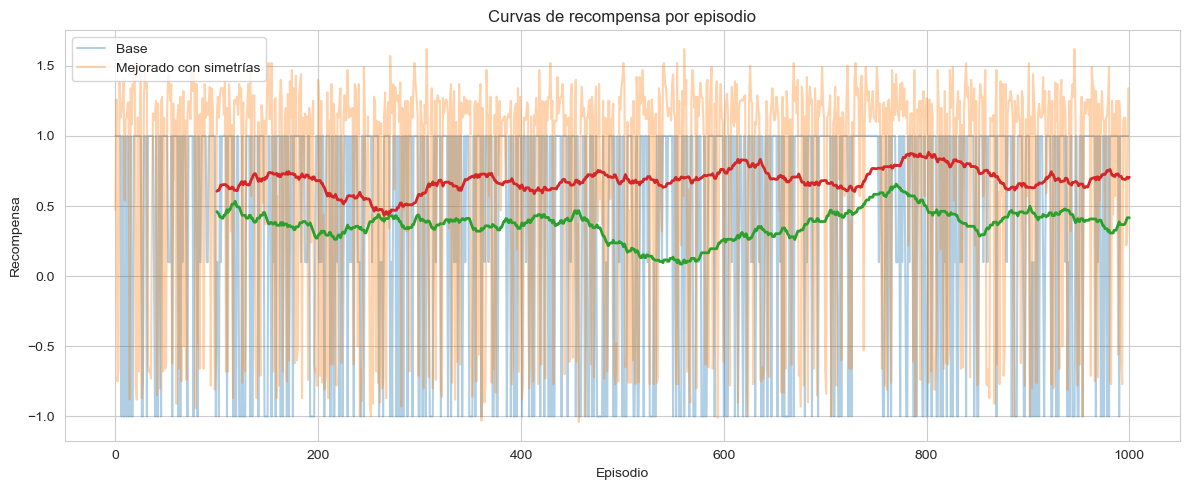

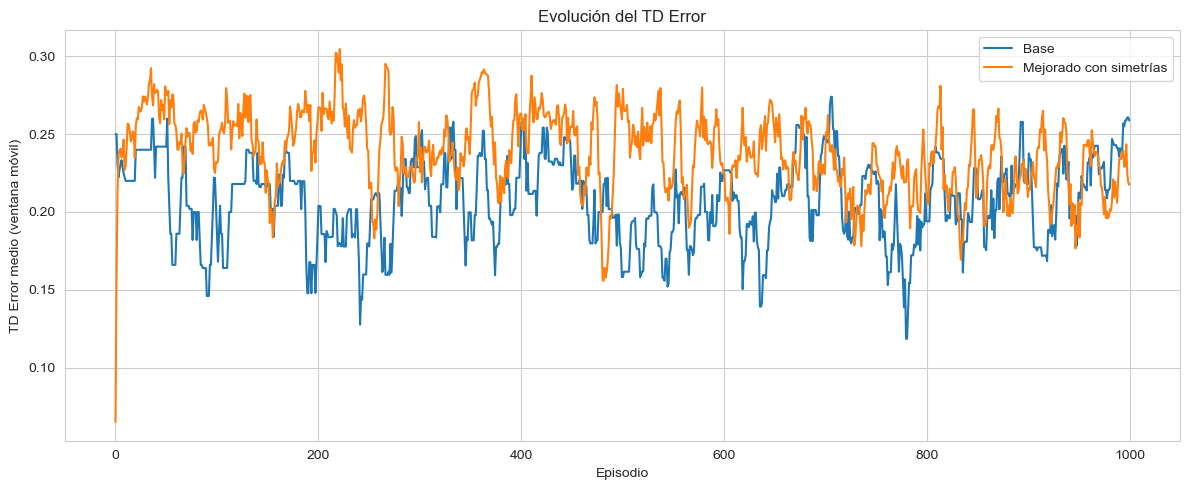

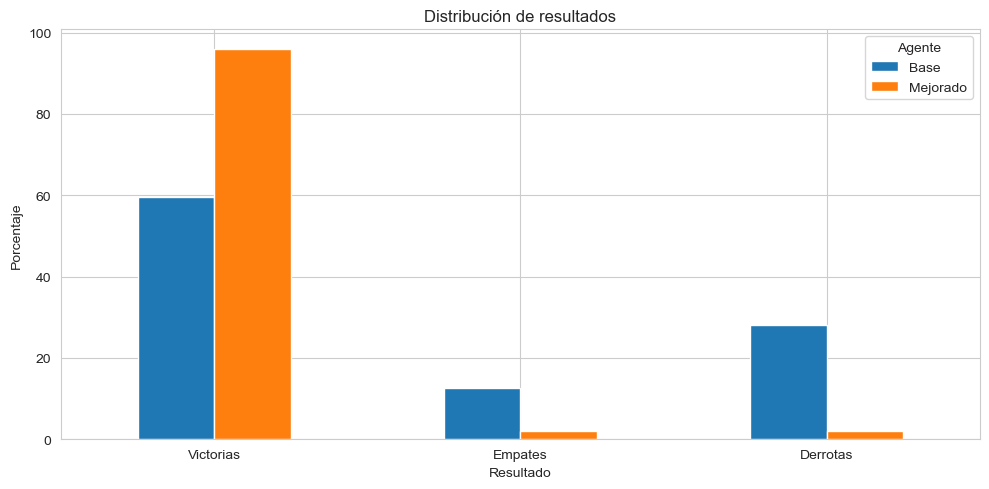

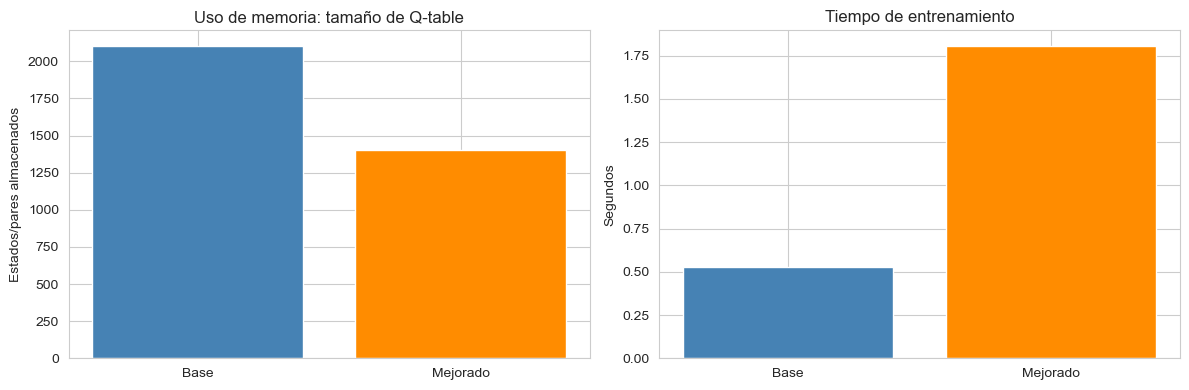

,Agente,Q-table,Tiempo(s)
0,Base,2103,0.528628
1,Mejorado,1406,1.805703


,Escenario,Agente,wins,losses,draws,total,win_rate
0,Inicio agente,Base,67,21,12,100,0.67
1,Inicio agente,Mejorado,95,3,2,100,0.95
2,Inicio oponente,Base,35,50,15,100,0.35
3,Inicio oponente,Mejorado,33,57,10,100,0.33
4,Tableros parciales,Base,81,7,12,100,0.81
5,Tableros parciales,Mejorado,85,4,11,100,0.85


Gráficas y tablas generadas correctamente en el notebook.


In [36]:
# =========================================
# Ejecución de Gráficas y Comparaciones
# =========================================

# Corrida corta de verificación para visualizar las gráficas en el notebook.
# Si quieres la corrida completa, usa BASE_TRAIN_EPISODES y BASE_TEST_GAMES.
VIS_TRAIN_EPISODES = 1000
VIS_EVAL_GAMES = 200
VIS_EVAL_INTERVAL = 250
VIS_ROBUSTNESS_GAMES = 100

base_summary = train_agent(
    make_base_agent,
    'Base',
    train_episodes=VIS_TRAIN_EPISODES,
    eval_games=VIS_EVAL_GAMES,
    eval_interval=VIS_EVAL_INTERVAL,
)

improved_summary = train_agent(
    make_canonical_agent,
    'Mejorado con simetrías',
    train_episodes=VIS_TRAIN_EPISODES,
    eval_games=VIS_EVAL_GAMES,
    eval_interval=VIS_EVAL_INTERVAL,
)

base_eval = evaluate_agent_custom(base_summary['agent'], num_games=VIS_EVAL_GAMES, agent_starts=True, training=False)
improved_eval = evaluate_agent_custom(improved_summary['agent'], num_games=VIS_EVAL_GAMES, agent_starts=True, training=False)

comparison_table = pd.DataFrame([
    {
        'Agente': 'Base',
        'Victorias': base_eval['wins'],
        'Empates': base_eval['draws'],
        'Derrotas': base_eval['losses'],
        'Win Rate (%)': base_eval['win_rate'] * 100,
        'Q-table': base_summary['final_q_size'],
    },
    {
        'Agente': 'Mejorado',
        'Victorias': improved_eval['wins'],
        'Empates': improved_eval['draws'],
        'Derrotas': improved_eval['losses'],
        'Win Rate (%)': improved_eval['win_rate'] * 100,
        'Q-table': improved_summary['final_q_size'],
    },
])

display(comparison_table)
plot_learning_curves(base_summary, improved_summary)
plot_td_errors(base_summary, improved_summary)
plot_result_distributions(base_eval, improved_eval)
plot_memory_and_time(base_summary, improved_summary)

robustness_table = robustness_report(
    base_summary['agent'],
    improved_summary['agent'],
    num_games=VIS_ROBUSTNESS_GAMES,
)

display(robustness_table)

print('Gráficas y tablas generadas correctamente en el notebook.')